In [1]:
import sys
import os
from pathlib import Path

# Make the repo root the working directory so relative paths resolve from there.
repo_root = Path.cwd().resolve()
if repo_root.name == "analysis_notebooks":
    repo_root = repo_root.parent
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

import xarray as xr
import matplotlib.pyplot as plt
import torch
import pandas as pd
import seaborn as sns
import numpy as np
from mpl_toolkits.basemap import Basemap
import geopandas as gpd
from esda.moran import Moran
from libpysal.weights import KNN
from eval.metrics import *
from eval.plot import *
import data.valid_crd as valid_crd
import glob
import os
import yaml
import data.helper as helper
from matplotlib.colors import ListedColormap
import math
import scipy.stats as stats
import statsmodels.api as sm
from collections import defaultdict

In [2]:
test_period = [1970, 2014]


exps = ['5fe5fe59'] #Final Repeat nowghtdecay, 5b
testep = [10]

base_dir = 'outputs/Final_repeat_nowghtdecay_5b/jobs_LOCAspatioTempConv1d' #Final Repeat nowghtdecay, 5b
save_path = f'plots' #Final Repeat


os.makedirs(save_path, exist_ok=True)

def load_model_run(run_id, est_period, epoch=None, base_dir=base_dir):


    run_path = helper.load_run_path(run_id, base_dir)

    flat_dir = os.path.join(run_path, f"{test_period[0]}_{test_period[1]}")

    future_path = os.path.join(run_path, "ssp5_8_5_2015_2099")

    # Check which structure exists
    data_path = flat_dir
    config_path = os.path.join(run_path, 'train_config.yaml')

    x = torch.load(os.path.join(data_path, 'x.pt'), map_location='cpu').squeeze(-1).numpy()
    x[x<0.254] = 0 
    y = torch.load(os.path.join(data_path, 'y.pt'), map_location='cpu').squeeze(-1).numpy()
    y[y<0.254] = 0
    time = torch.load(os.path.join(data_path, 'time.pt'), map_location='cpu')

    xt = None
    if epoch is not None:
        xt_path = os.path.join(data_path, f'ep{epoch}', 'xt.pt')
        if os.path.exists(xt_path):
            xt = torch.load(xt_path, map_location='cpu')
        else:
            print(run_id)
        xt[xt<0.254] = 0

    
    # future_x= None; future_xt = None; future_time = None
    future_x = torch.load(os.path.join(future_path, 'x.pt'), map_location='cpu').squeeze(-1).numpy()
    future_x[future_x<0.254] = 0 
    future_time = torch.load(os.path.join(future_path, 'time.pt'), map_location='cpu')

    
    future_xt = torch.load(os.path.join(future_path, 'xt.pt'), map_location='cpu')
    future_xt[future_xt<0.254] = 0

    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    return {
        'run_path': run_path,
        'x': x,
        'y': y,
        'time': time,
        'xt': xt,
        'future_x': future_x,
        'future_xt': future_xt,
        'future_time': future_time,
        'config': config
    }

models = []
for i in range(len(exps)):
    model = load_model_run(exps[i], test_period, epoch=testep[i])
    models.append(model)

In [3]:
valid_coords = []
loca_all = []
QM_all = []
QM_delta_all = []
ISIMIP_all = []
ECDFM_all = []


loca_future_all = []
QM_future_all = []
QM_delta_future_all = []
ISIMIP_future_all = []
ECDFM_future_all = []

for i in range(len(models)):
    
    cmip6_dir = models[i]['config']['cmip_dir']
    clim = models[i]['config']['clim']
    ref = models[i]['config']['ref']
    train_period = [models[i]['config']['train_start'], models[i]['config']['train_end']]
    # future_period = [models[i]['config']['trend_start'], models[i]['config']['trend_end']]
    future_period = [2015, 2099]

    ds_sample = xr.open_dataset(f"{cmip6_dir}/{clim}/historical/precipitation/clipped_US.nc")

    shapefile_path = None if not  models[i]['config']['spatial_test']  else models[i]['config']['shapefile_filter_path']
    
    try:
        spatial_extent = models[i]['config']['spatial_extent_test']
    except:
        spatial_extent = models[i]['config']['spatial_extent_val']

    valid_coords.append(valid_crd.valid_lat_lon(ds_sample, var_name='pr', shapefile_path=shapefile_path, attrList=spatial_extent))


    #loading loca

    loca = xr.open_dataset(f'{cmip6_dir}/{clim}/historical/precipitation/loca/coarse_USclip.nc')
    loca = loca['pr'].sel(lat=xr.DataArray(valid_coords[i][:, 0], dims='points'),
                                        lon=xr.DataArray(valid_coords[i][:, 1], dims='points'),
                                        method='nearest')
    loca = loca.sel(time =slice(f'{test_period[0]}', f'{test_period[1]}')).values

    #unit conversion
    loca_all.append(loca*86400)



    # if 'QM' in method_names:
    QM_bench = f'benchmark/QuantileMapping/conus/{clim}-{ref}/{train_period}_historical_{test_period}.pt'
    QM_debiased = torch.load(QM_bench, weights_only=False).squeeze(-1)
    QM_all.append(QM_debiased*86400)

    QM_future_bench = f'benchmark/QuantileMapping/conus/{clim}-{ref}/{train_period}_ssp5_8_5_{future_period}.pt'
    QM_future_debiased = torch.load(QM_future_bench, weights_only=False).squeeze(-1)
    QM_future_all.append(QM_future_debiased*86400)



    QM_delta_bench = f'benchmark/QuantileDeltaMapping/conus/{clim}-{ref}/{train_period}_historical_{test_period}.pt'
    QM_delta_debiased = torch.load(QM_delta_bench, weights_only=False).squeeze(-1)
    QM_delta_all.append(QM_delta_debiased*86400)

    QM_delta_future_bench = f'benchmark/QuantileDeltaMapping/conus/{clim}-{ref}/{train_period}_ssp5_8_5_{future_period}.pt'
    QM_delta_future_debiased = torch.load(QM_delta_future_bench, weights_only=False).squeeze(-1)
    QM_delta_future_all.append(QM_delta_future_debiased*86400)



    ISIMIP_bench = f'benchmark/ISIMIP/conus/{clim}-{ref}/{train_period}_historical_{test_period}.pt'
    ISIMIP_debiased = torch.load(ISIMIP_bench, weights_only=False).squeeze(-1)
    ISIMIP_all.append(ISIMIP_debiased*86400)

    ISIMIP_future_bench = f'benchmark/ISIMIP/conus/{clim}-{ref}/{train_period}_ssp5_8_5_{future_period}.pt'
    ISIMIP_future_debiased = torch.load(ISIMIP_future_bench, weights_only=False).squeeze(-1)
    ISIMIP_future_all.append(ISIMIP_future_debiased*86400)

    ECDFM_bench = f'benchmark/ECDFM/conus/{clim}-{ref}/{train_period}_historical_{test_period}.pt'
    ECDFM_debiased = torch.load(ECDFM_bench, weights_only=False).squeeze(-1)
    ECDFM_all.append(ECDFM_debiased*86400)  

    ECDFM_future_bench = f'benchmark/ECDFM/conus/{clim}-{ref}/{train_period}_ssp5_8_5_{future_period}.pt'
    ECDFM_future_debiased = torch.load(ECDFM_future_bench, weights_only=False).squeeze(-1)
    ECDFM_future_all.append(ECDFM_future_debiased*86400)

    loca_future1 = xr.open_dataset(f'{cmip6_dir}/{clim}/ssp5_8_5/precipitation/loca/coarse_USclip1.nc')
    loca_future1 = loca_future1['pr'].sel(lat=xr.DataArray(valid_coords[i][:, 0], dims='points'),
                                        lon=xr.DataArray(valid_coords[i][:, 1], dims='points'),
                                        method='nearest').values

    loca_future2 = xr.open_dataset(f'{cmip6_dir}/{clim}/ssp5_8_5/precipitation/loca/coarse_USclip2.nc')
    loca_future2 = loca_future2['pr'].sel(lat=xr.DataArray(valid_coords[i][:, 0], dims='points'),
                                        lon=xr.DataArray(valid_coords[i][:, 1], dims='points'),
                                        method='nearest').values

    loca_future3 = xr.open_dataset(f'{cmip6_dir}/{clim}/ssp5_8_5/precipitation/loca/coarse_USclip.nc')
    loca_future3 = loca_future3['pr'].sel(lat=xr.DataArray(valid_coords[i][:, 0], dims='points'),
                                        lon=xr.DataArray(valid_coords[i][:, 1], dims='points'),
                                        method='nearest').values
    loca_future = np.concatenate([loca_future1, loca_future2, loca_future3], axis=0)
    loca_future_all.append(loca_future*86400)

In [4]:
## this block filters 'y' based on 'x' calender
counter = 0
for model in models:
    time = model['time']
    
    x_time_np = np.array([pd.Timestamp(str(t)) for t in time])
    x_time_np = np.array([pd.Timestamp(t).replace(hour=0, minute=0, second=0) for t in x_time_np], dtype='datetime64[D]')
    # Generate a daily time array following the standard Gregorian calendar
    y_time = pd.date_range(start=f"{test_period[0]}-01-01", end=f"{test_period[1]}-12-31", freq="D")

    # Convert to NumPy array for indexing and comparison
    y_time_np = y_time.to_numpy()

    # Find indices where observed time matches model time
    matched_indices = np.where(np.isin(y_time_np, x_time_np))[0]

    model['y'] = model['y'][matched_indices,:]
    model['x_time_np'] = x_time_np

    loca_all[counter] = loca_all[counter][matched_indices, :]

    future_time = model['future_time']

    future_period = [2015, 2099]


    future_x_time = np.array([pd.Timestamp(str(t)) for t in future_time])
    future_x_time = np.array([pd.Timestamp(t).replace(hour=0, minute=0, second=0) for t in future_x_time], dtype='datetime64[D]')

    future_all_time = pd.date_range(start=f"{future_period[0]}-01-01", end=f"{future_period[1]}-12-31", freq="D")
    future_all_time_np = future_all_time.to_numpy()

    future_matched_indices = np.where(np.isin(future_all_time_np, future_x_time))[0]

    model['future_time'] = future_x_time

    counter+=1

## Ibicus (Simple Way)

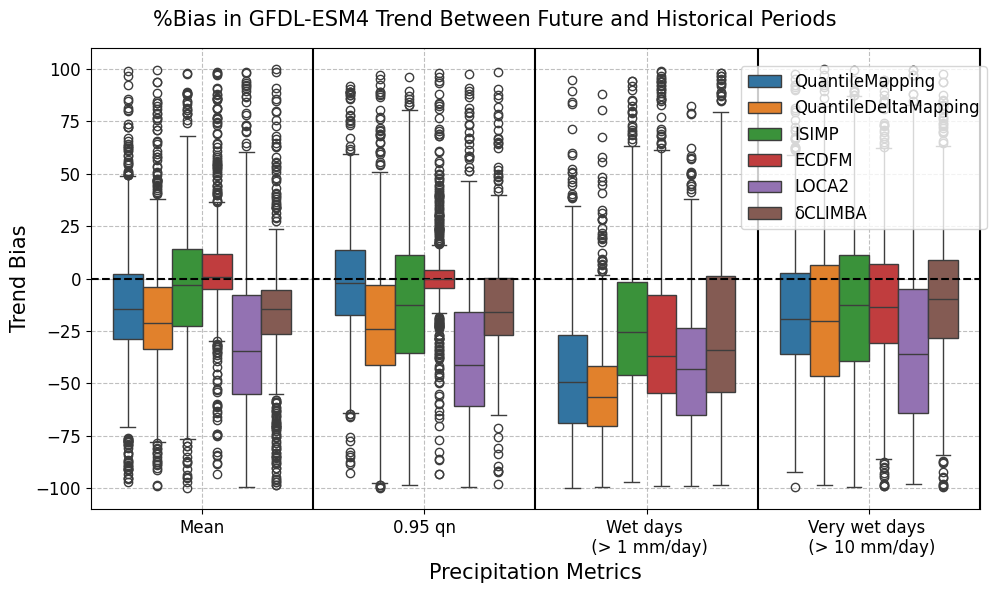

In [5]:
from ibicus.evaluate.metrics import *
from ibicus.evaluate import assumptions, correlation, marginal, multivariate, trend


violin_method_names = [
    "δCLIMBA",
    "QuantileMapping",
    "ISIMIP",
    "ECDFM",
    "QuantileDeltaMapping",
    "LOCA2",
]

unique_methods = ["Raw"] + violin_method_names
color_palette = sns.color_palette("husl", len(unique_methods))
violin_color_mapping = {m: color_palette[i] for i, m in enumerate(unique_methods)}

# Darken colors a bit while preserving relative hues
darken_factor = 0.8
violin_color_mapping_dark = {
    k: tuple(np.clip(np.array(v) * darken_factor, 0, 1))
    for k, v in violin_color_mapping.items()
}


pr_metrics = [wet_days, R10mm]

i=0

x = np.expand_dims(models[i]['x'], axis=-1)/86400
xt = np.expand_dims(models[i]['xt'], axis=-1)/86400
future_x = np.expand_dims(models[i]['future_x'], axis=-1)/86400
future_xt = np.expand_dims(models[i]['future_xt'], axis=-1)/86400
QM_ = np.expand_dims(QM_all[i], axis=-1)/86400
future_QM_ = np.expand_dims(QM_future_all[i], axis=-1)/86400

QM_delta_ = np.expand_dims(QM_delta_all[i], axis=-1)/86400
future_QM_delta_ = np.expand_dims(QM_delta_future_all[i], axis=-1)/86400

ISIMIP_ = np.expand_dims(ISIMIP_all[i], axis=-1)/86400
future_ISIMIP_ = np.expand_dims(ISIMIP_future_all[i], axis=-1)/86400

ECDFM_ = np.expand_dims(ECDFM_all[i], axis=-1)/86400
future_ECDFM_ = np.expand_dims(ECDFM_future_all[i], axis=-1)/86400

loca_ = np.expand_dims(loca_all[i], axis=-1)/86400
future_loca_ = np.expand_dims(loca_future_all[i], axis=-1)/86400


trend_bias_data = trend.calculate_future_trend_bias(statistics = ["mean", 0.95], 
                                                    trend_type = 'additive',
                                            raw_validate = x, raw_future = future_x,
                                                    metrics = pr_metrics,
                                            QuantileMapping = [QM_, future_QM_],
                                            QuantileDeltaMapping = [QM_delta_, future_QM_delta_],
                                            ISIMP = [ISIMIP_, future_ISIMIP_],
                                            ECDFM = [ECDFM_, future_ECDFM_],
                                            LOCA2 = [loca_, future_loca_],
                                            δCLIMBA = [xt, future_xt])


trend_plot = trend.plot_future_trend_bias_boxplot(variable ='pr', 
                                            bias_df = trend_bias_data, 
                                            remove_outliers = True,
                                            outlier_threshold = 100)

# Get all legend handles and labels from the plot
handles, labels = trend_plot.gca().get_legend_handles_labels()

# Remove any existing legends and titles
for ax in trend_plot.get_axes():
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()
    ax.set_title('')  # Clear the title

plt.suptitle("%Bias in GFDL-ESM4 Trend Between Future and Historical Periods", fontsize=15)

# Add a single legend to the figure, positioned below the title
trend_plot.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.0,0.9), fontsize=12)

# Set labels and title using the figure's current axes
plt.sca(trend_plot.gca())  # Set current axes
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Precipitation Metrics', fontsize=15)
plt.ylabel('Trend Bias', fontsize=15)
plt.grid(True, alpha=0.8, linestyle='--', linewidth=0.8)

plt.tight_layout()
# plt.savefig(f'{save_path}/ibicus_fig2.png', dpi=300, bbox_inches='tight')
plt.show()